In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
import matplotlib.pyplot as plt

import kind
import ex_duffing
import util_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--file_dir', '../../data/dreamer',
        '--file_name', 'duffing',
        '--data_nsample', '3848',
        '--feature_ndim', '4',
        '--target_ndim', '2',
        '--data_train_size', '0.8',

        '--lookback_nsample', '384',
        '--forecast_nsample', '192',

        '--batch_size', '128',
        '--nepoch', '100',
        '--patience', '20',
        '--checkpoints', '../../models/dreamer',

        '--seg_nsample_stat', '192',
        '--seg_nsample_trans', '192',
        '--fun_stat', '{"sin": 4, "cos": 4}',
        '--fun_trans', '{"data": 12}',
    ]
)

setpoint = [1.0, 0.0]

In [3]:
model = kind.model(args)

dataset = ex_duffing.dataset(
    args.file_dir, args.file_name, args.file_index, args.file_ext,
    args.data_nsample,
    (args.data_train_size, args.data_test_size),
    args.batch_size, (args.lookback_nsample, args.forecast_nsample), setpoint, load_normalized=True)

training = kind.training(model)

In [4]:
model.train()
training.fit(dataset)

>>> training nominal mean >>>
	epoch 1 losses: train=0.314919, valid=0.246311, test=0.246047
	validation loss decreased (inf -> 0.246311), saving model ...
	epoch 2 losses: train=0.243560, valid=0.241895, test=0.241503
	validation loss decreased (0.246311 -> 0.241895), saving model ...
	epoch 3 losses: train=0.241392, valid=0.241543, test=0.241149
	validation loss decreased (0.241895 -> 0.241543), saving model ...
	epoch 4 losses: train=0.241136, valid=0.241220, test=0.240827
	validation loss decreased (0.241543 -> 0.241220), saving model ...
	epoch 5 losses: train=0.236535, valid=0.215096, test=0.216351
	validation loss decreased (0.241220 -> 0.215096), saving model ...
	epoch 6 losses: train=0.153188, valid=0.102205, test=0.106263
	validation loss decreased (0.215096 -> 0.102205), saving model ...
	epoch 7 losses: train=0.047460, valid=0.011286, test=0.011217
	validation loss decreased (0.102205 -> 0.011286), saving model ...
	epoch 8 losses: train=0.006219, valid=0.003448, test=0.00

In [5]:
model.eval()
_, _, data_loader = dataset.load(data_type='nom')

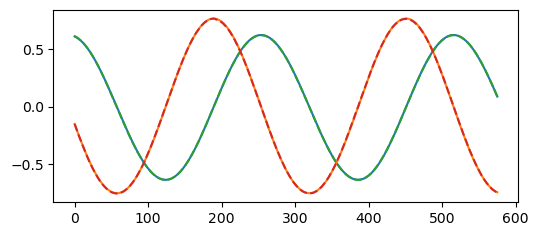

In [6]:
jdata = 2

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]

        plt.figure(figsize=(6,2.5))
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.show()

        break


In [7]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training nominal uncertainty >>>
	epoch 1 losses: train=0.104243, valid=0.068140, test=0.068201
	validation loss decreased (inf -> 0.068140), saving model ...
	epoch 2 losses: train=0.064607, valid=0.048807, test=0.048452
	validation loss decreased (0.068140 -> 0.048807), saving model ...
	epoch 3 losses: train=0.026707, valid=0.020730, test=0.020738
	validation loss decreased (0.048807 -> 0.020730), saving model ...
	epoch 4 losses: train=0.019953, valid=0.019943, test=0.019939
	validation loss decreased (0.020730 -> 0.019943), saving model ...
	epoch 5 losses: train=0.019822, valid=0.019880, test=0.019890
	validation loss decreased (0.019943 -> 0.019880), saving model ...
	epoch 6 losses: train=0.019816, valid=0.019912, test=0.019888
	early stopping counter: 1 out of 20
	epoch 7 losses: train=0.019796, valid=0.019932, test=0.019964
	early stopping counter: 2 out of 20
	epoch 8 losses: train=0.019826, valid=0.019921, test=0.019917
	early stopping counter: 3 out of 20
	epoch 9 loss

In [8]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

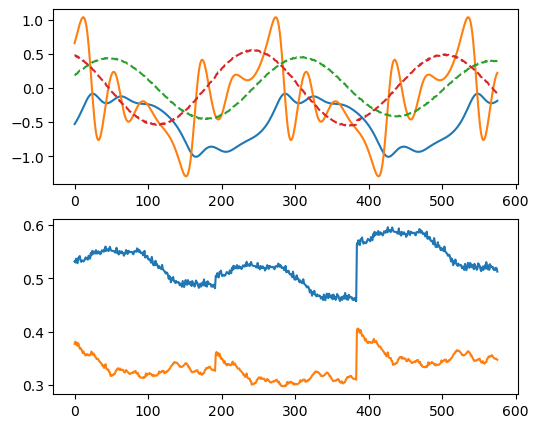

In [9]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]
        stat_u = model_output[2]

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(stat_u[0, :, :2])

        plt.show()

        break


In [10]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion mean >>>
	epoch 1 losses: train=0.356197, valid=0.254655, test=0.254124
	validation loss decreased (inf -> 0.254655), saving model ...
	epoch 2 losses: train=0.213045, valid=0.190179, test=0.190199
	validation loss decreased (0.254655 -> 0.190179), saving model ...
	epoch 3 losses: train=0.188155, valid=0.186459, test=0.186473
	validation loss decreased (0.190179 -> 0.186459), saving model ...
	epoch 4 losses: train=0.186139, valid=0.185348, test=0.185441
	validation loss decreased (0.186459 -> 0.185348), saving model ...
	epoch 5 losses: train=0.183255, valid=0.177706, test=0.177976
	validation loss decreased (0.185348 -> 0.177706), saving model ...
	epoch 6 losses: train=0.172421, valid=0.160196, test=0.160900
	validation loss decreased (0.177706 -> 0.160196), saving model ...
	epoch 7 losses: train=0.143447, valid=0.128394, test=0.128732
	validation loss decreased (0.160196 -> 0.128394), saving model ...
	epoch 8 losses: train=0.111387, valid=0.082667, test=0.

In [11]:
model.eval()
_, _, data_loader = dataset.load(data_type='exc')

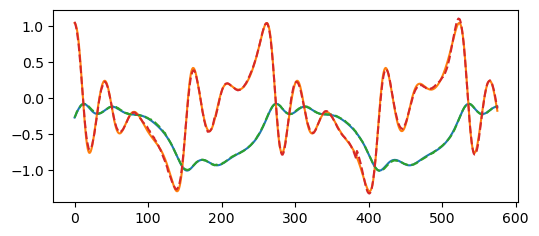

In [12]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[3]

        plt.figure(figsize=(6,2.5))
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.show()

        break

In [13]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion uncertainty >>>
	epoch 1 losses: train=0.125251, valid=0.076611, test=0.076479
	validation loss decreased (inf -> 0.076611), saving model ...
	epoch 2 losses: train=0.048510, valid=0.032145, test=0.032022
	validation loss decreased (0.076611 -> 0.032145), saving model ...
	epoch 3 losses: train=0.029503, valid=0.028301, test=0.028091
	validation loss decreased (0.032145 -> 0.028301), saving model ...
	epoch 4 losses: train=0.027854, valid=0.027719, test=0.027549
	validation loss decreased (0.028301 -> 0.027719), saving model ...
	epoch 5 losses: train=0.027521, valid=0.027745, test=0.027540
	early stopping counter: 1 out of 20
	epoch 6 losses: train=0.027403, valid=0.027278, test=0.027108
	validation loss decreased (0.027719 -> 0.027278), saving model ...
	epoch 7 losses: train=0.026887, valid=0.026850, test=0.026586
	validation loss decreased (0.027278 -> 0.026850), saving model ...
	epoch 8 losses: train=0.026319, valid=0.026093, test=0.025874
	validation loss 

In [14]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

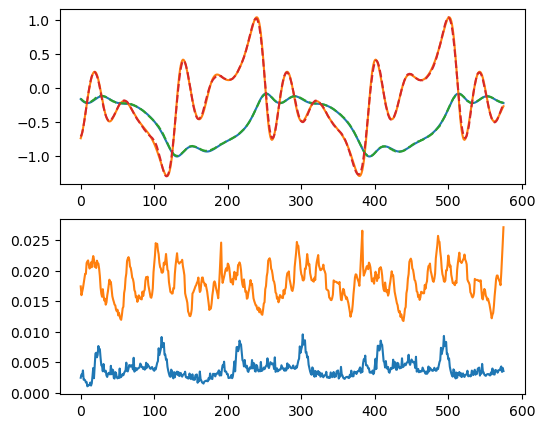

In [15]:
jdata = 3

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        exc = model_output[3]
        exc_u = model_output[4]

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(exc[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(exc_u[0, :, :2])

        plt.show()

        break

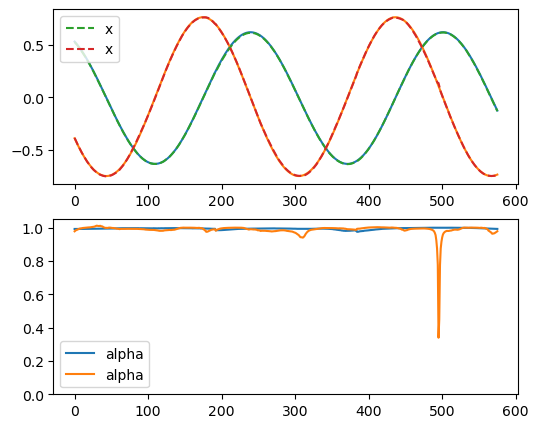

In [17]:
jdata = 2

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        pre = model_output[0]
        alpha = model_output[9]

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(pre[0, :, :2], linestyle='dashed', label='x')
        plt.legend()

        plt.subplot(2,1,2)
        plt.plot(alpha[0, :, :2], label='alpha')
        plt.ylim((0.0, 1.05))
        plt.legend()

        plt.show()

        break